# Used Car Price Prediction using Random Forest Regression

### Name:
### Roll No:
### Course:

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

## Task 1: Load Dataset

In [6]:
df = pd.read_csv("../data/car_data.csv")


In [7]:
df.head(10)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [8]:
df.shape

(301, 9)

In [9]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [11]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In this task, the CarDekho Used Car Dataset is loaded using Pandas. The dataset structure, column names, data types, and summary statistics are explored.

## Task 2 : Exploratory Data Analysis (EDA)

In [12]:

df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [13]:

df.duplicated().sum()

np.int64(2)

In [14]:
df = df.drop_duplicates()

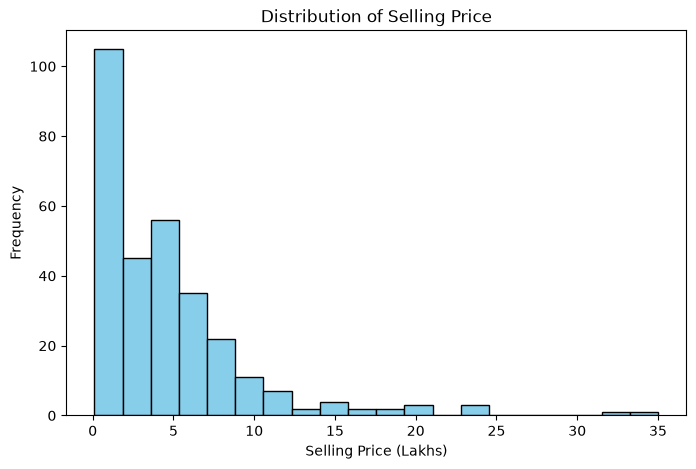

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df['Selling_Price'], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Frequency")
plt.show()

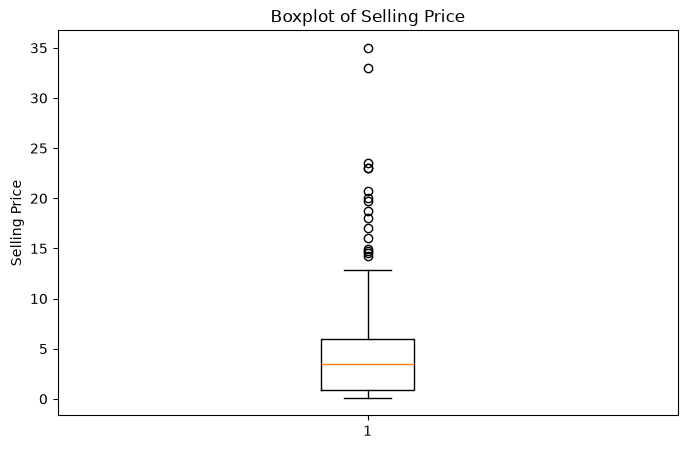

In [16]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Selling_Price'])
plt.title("Boxplot of Selling Price")
plt.ylabel("Selling Price")
plt.show()

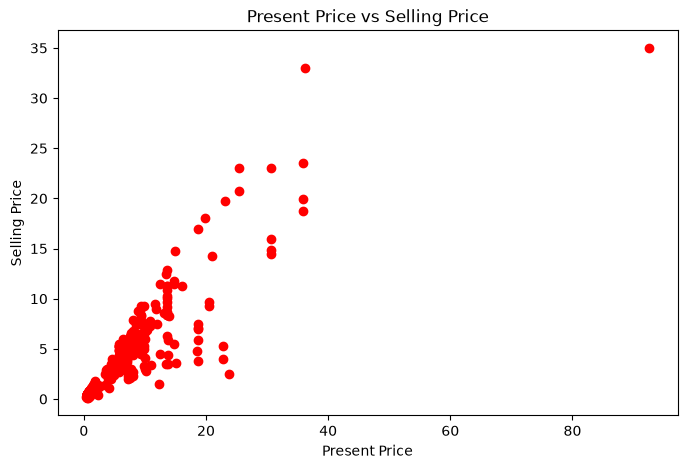

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df['Present_Price'], df['Selling_Price'], color='red')
plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.show()

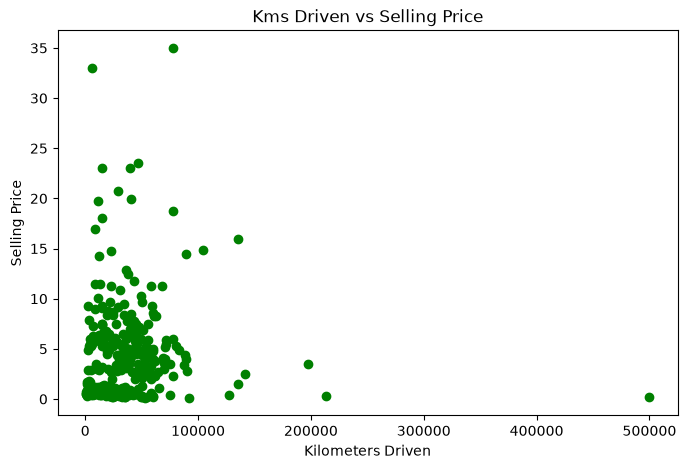

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df['Kms_Driven'], df['Selling_Price'], color='green')
plt.title("Kms Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.show()

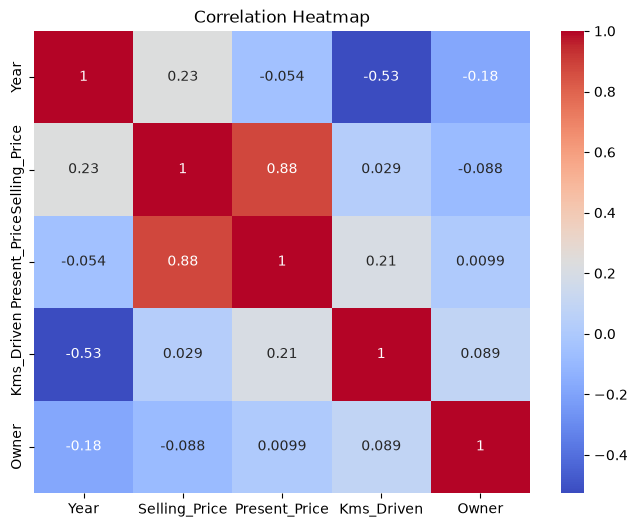

In [19]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [20]:
### EDA Observations

- No missing values found.
- Duplicate records checked.
- Selling Price distribution observed.
- Outliers identified using boxplot.
- Scatter plots show relationship between variables.
- Correlation heatmap helps identify highly correlated features.

SyntaxError: invalid syntax (785729947.py, line 3)

Exploratory Data Analysis (EDA) is performed to understand the dataset by checking missing values, duplicates, descriptive statistics, and visualizing the data using graphs.

## Task 3 : Feature Engineering

In this task, we create new features to improve the model's prediction performance.

Features Created:
- Car_Age
- Mileage_per_Year
- Premium_Brand
- High_Mileage

In [ ]:
# ==============================
# Task 3 : Feature Engineering
# ==============================

# 1. Car Age
df["Car_Age"] = 2025 - df["Year"]

# 2. Mileage Per Year
df["Mileage_per_Year"] = df["Kms_Driven"] / (df["Car_Age"] + 1)

# 3. Premium Brand
premium_brands = [
    "fortuner", "innova", "corolla", "corolla altis",
    "camry", "land cruiser",
    "city", "brio", "jazz", "amaze",
    "creta", "verna", "elantra",
    "i20", "i10", "grand i10", "eon", "xcent"
]

df["Premium_Brand"] = df["Car_Name"].apply(
    lambda x: 1 if x.lower() in premium_brands else 0
)

# 4. High Mileage
median_km = df["Kms_Driven"].median()

df["High_Mileage"] = np.where(
    df["Kms_Driven"] > median_km,
    1,
    0
)

# Display first 10 records with new features
df.head(10)

## Task 4 : Data Transformation (Encoding)

Machine Learning models cannot understand categorical (text) data directly. Therefore, Label Encoding is applied to convert text values into numerical values.

### Difference Between Label Encoding and One-Hot Encoding

**Label Encoding**
- Converts each category into a unique integer.
- Suitable for tree-based models like Random Forest.
- Example:
  - Petrol → 0
  - Diesel → 1
  - CNG → 2

**One-Hot Encoding**
- Creates separate binary columns for each category.
- Suitable for linear models when categories have no natural order.

New features such as Car_Age, Mileage_per_Year, Premium_Brand, and High_Mileage are created to improve the model's performance.

In [ ]:
# ==============================
# Task 4 : Data Transformation
# ==============================

# Create LabelEncoder object
le = LabelEncoder()

# Encode categorical columns
categorical_columns = [
    "Car_Name",
    "Fuel_Type",
    "Seller_Type",
    "Transmission"
]

for column in categorical_columns:
    df[column] = le.fit_transform(df[column])

# Display first 10 rows
df.head(10)

In [ ]:
df.info()


Categorical variables cannot be directly used by machine learning algorithms. Therefore, Label Encoding is applied to convert categorical features into numerical values before training the model.

## Task 5 : Train-Test Split

The dataset is divided into training and testing sets.

- Training Data: 80%
- Testing Data: 20%
- Random State: 42

The target variable is **Selling_Price**, while the remaining columns are used as input features.

In [ ]:
# ==============================
# Task 5 : Train-Test Split
# ==============================

# Features (Independent Variables)
X = df.drop("Selling_Price", axis=1)

# Target Variable (Dependent Variable)
y = df["Selling_Price"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display shapes
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)



The dataset is divided into training and testing sets using an 80:20 ratio. The training data is used to train the model, while the testing data is used to evaluate its performance.

## Task 6 : Random Forest Regression

A Random Forest Regressor is trained using:

- n_estimators = 100
- random_state = 42

### Explanation

**n_estimators**
- Number of decision trees in the forest.
- More trees generally improve accuracy but increase training time.

**random_state**
- Ensures reproducible results.
- Using the same value gives the same train-test split and model behavior every time.

In [ ]:
# ==============================
# Task 6 : Random Forest Regression
# ==============================

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")



A Random Forest Regressor model is trained using the training dataset. Random Forest combines multiple decision trees to produce accurate and robust predictions while reducing overfitting.

## Task 7 : Model Prediction

The trained Random Forest Regression model is used to predict the selling prices of the test dataset.

The predicted prices are compared with the actual selling prices to evaluate the model's performance.

In [ ]:
# ==============================
# Task 7 : Model Prediction
# ==============================

# Predict selling prices
y_pred = rf_model.predict(X_test)

# Compare Actual vs Predicted Prices
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

# Display first 10 predictions
comparison.head(10)


In [ ]:
# Plot Actual vs Predicted Prices

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    color="blue",
    alpha=0.7
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.show()



The trained Random Forest model is used to predict the selling prices of cars in the test dataset. The predicted values are compared with the actual selling prices to evaluate prediction accuracy.

## Task 8 : Model Evaluation

The performance of the Random Forest Regression model is evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

### Interpretation

- **MAE:** Average prediction error. Lower values indicate better performance.
- **MSE:** Average of squared prediction errors. Lower values are better.
- **RMSE:** Square root of MSE. It is in the same unit as the target variable.
- **R² Score:** Indicates how well the model explains the variance in the data. A value closer to 1 indicates better performance.

In [ ]:
# ==============================
# Task 8 : Model Evaluation
# ==============================

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
print("Model Evaluation Metrics")
print("-" * 35)

print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Mean Squared Error (MSE)  : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")



The model performance is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. These metrics indicate how accurately the model predicts car prices.

## Task 9 : Hyperparameter Tuning using GridSearchCV

GridSearchCV is used to find the best combination of hyperparameters for the Random Forest Regressor.

Parameters Tuned:
- n_estimators
- max_depth
- min_samples_split
- min_samples_leaf

The model is evaluated using 5-fold cross-validation.

In [ ]:
# ==============================
# Task 9 : Hyperparameter Tuning
# ==============================

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train GridSearchCV
grid_search.fit(X_train, y_train)

# Best Results
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)



GridSearchCV is used to find the optimal combination of hyperparameters for the Random Forest model. This helps improve prediction accuracy and overall model performance.

## Task 10 : Feature Importance

Feature Importance shows which input variables contribute the most to predicting the selling price.

In [ ]:
# ==============================
# Task 10 : Feature Importance
# ==============================

# Best model from GridSearchCV
best_model = grid_search.best_estimator_

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

# Sort values
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance'],
    color='steelblue'
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()



Feature importance is calculated to identify which input features contribute the most to predicting the selling price. The results are displayed using a bar chart for better interpretation.

### Observation

- The feature with the highest importance contributes the most to predicting the selling price.
- The feature with the lowest importance contributes the least.
- The result is practically meaningful because features such as Present_Price and Car_Age generally have a strong influence on the resale value of a vehicle.

## Task 11 : Predict a New Car Price

The trained model is used to estimate the selling price of a new vehicle based on user inputs.

In [ ]:
le = LabelEncoder()

categorical_columns = [
    "Car_Name",
    "Fuel_Type",
    "Seller_Type",
    "Transmission"
]

for column in categorical_columns:
    df[column] = le.fit_transform(df[column])
encoders = {}

categorical_columns = [
    "Car_Name",
    "Fuel_Type",
    "Seller_Type",
    "Transmission"
]

for column in categorical_columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    encoders[column] = le

## Task 11 : Predict a New Car Price

The trained Random Forest model predicts the selling price of a new car using user-provided details.

In [ ]:
# User Inputs

car_name = input("Enter Car Name: ").strip().lower()
year = int(input("Enter Year: "))
present_price = float(input("Enter Present Price: "))
kms_driven = int(input("Enter Kilometers Driven: "))
fuel_type = input("Enter Fuel Type (Petrol/Diesel/CNG): ").strip()
seller_type = input("Enter Seller Type (Dealer/Individual): ").strip()
transmission = input("Enter Transmission (Manual/Automatic): ").strip()
owner = int(input("Enter Owner Count: "))

# Feature Engineering

car_age = 2025 - year
mileage_per_year = kms_driven / (car_age + 1)

premium_brands = [
    "fortuner", "innova", "corolla", "corolla altis",
    "camry", "land cruiser",
    "city", "brio", "jazz", "amaze",
    "creta", "verna", "elantra",
    "i20", "i10", "grand i10", "eon", "xcent"
]

premium_brand = 1 if car_name in premium_brands else 0

median_km = df["Kms_Driven"].median()
high_mileage = 1 if kms_driven > median_km else 0

# Check if car exists in dataset

if car_name not in [x.lower() for x in encoders["Car_Name"].classes_]:
    print("\nCar Name not found in dataset!")
else:

    # Encode Inputs

    car_name_encoded = encoders["Car_Name"].transform([car_name])[0]
    fuel_type_encoded = encoders["Fuel_Type"].transform([fuel_type])[0]
    seller_type_encoded = encoders["Seller_Type"].transform([seller_type])[0]
    transmission_encoded = encoders["Transmission"].transform([transmission])[0]

    # Create DataFrame

    new_car = pd.DataFrame({
        "Car_Name": [car_name_encoded],
        "Year": [year],
        "Present_Price": [present_price],
        "Kms_Driven": [kms_driven],
        "Fuel_Type": [fuel_type_encoded],
        "Seller_Type": [seller_type_encoded],
        "Transmission": [transmission_encoded],
        "Owner": [owner],
        "Car_Age": [car_age],
        "Mileage_per_Year": [mileage_per_year],
        "Premium_Brand": [premium_brand],
        "High_Mileage": [high_mileage]
    })

    # Prediction

    prediction = best_model.predict(new_car)

    print("\n==============================")
    print(f"Estimated Selling Price = ₹ {prediction[0]:.2f} Lakhs")
    print("==============================")

In [ ]:
import joblib

joblib.dump(best_model, "used_car_price_model.pkl")

print("Model saved successfully!")



The trained model is used to predict the selling price of a new used car based on user-provided input such as car name, year, present price, fuel type, transmission, seller type, kilometers driven, and owner information.